In [1]:
# Part 4 — Vector Databases  
## Embedding & Similarity Demo

In [2]:
%pip install sentence-transformers seaborn scikit-learn

     -------------------------------------- 512.4/512.4 KB 6.4 MB/s eta 0:00:00
     -------------------------------------- 113.7/113.7 MB 8.3 MB/s eta 0:00:00
     -------------------------------------- 618.0/618.0 KB 9.8 MB/s eta 0:00:00
     ---------------------------------------- 78.4/78.4 KB 4.3 MB/s eta 0:00:00
     --------------------------------------- 10.7/10.7 MB 11.3 MB/s eta 0:00:00
     -------------------------------------- 158.6/158.6 KB 9.3 MB/s eta 0:00:00
     ---------------------------------------- 73.5/73.5 KB 4.2 MB/s eta 0:00:00
     -------------------------------------- 202.5/202.5 KB 6.2 MB/s eta 0:00:00
     ---------------------------------------- 56.1/56.1 KB 2.9 MB/s eta 0:00:00
     ---------------------------------------- 3.7/3.7 MB 11.7 MB/s eta 0:00:00
     -------------------------------------- 134.9/134.9 KB 7.8 MB/s eta 0:00:00
     ---------------------------------------- 1.7/1.7 MB 11.0 MB/s eta 0:00:00
     -------------------------------------

You should consider upgrading via the 'c:\Users\Pernytha\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [3]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

c:\Users\Pernytha\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
sentences = [
    # Cricket
    "The batsman scored a century in the final match.",
    "The bowler delivered a fast yorker that hit the stumps.",
    "The cricket team celebrated their victory after the thrilling chase.",
    "Fielders quickly gathered around after the wicket was taken.",
    
    # Cooking
    "The chef slowly stirred the pasta sauce to enhance the flavor.",
    "Baking bread requires patience and the right amount of yeast.",
    "She chopped fresh vegetables before adding them to the soup.",
    
    # Cybersecurity
    "Strong passwords help protect accounts from hackers.",
    "Cybersecurity experts monitor networks to detect suspicious activity.",
    "Encryption ensures that sensitive data remains secure."
]

In [5]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

c:\Users\Pernytha\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Pernytha\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6059.26it/s]


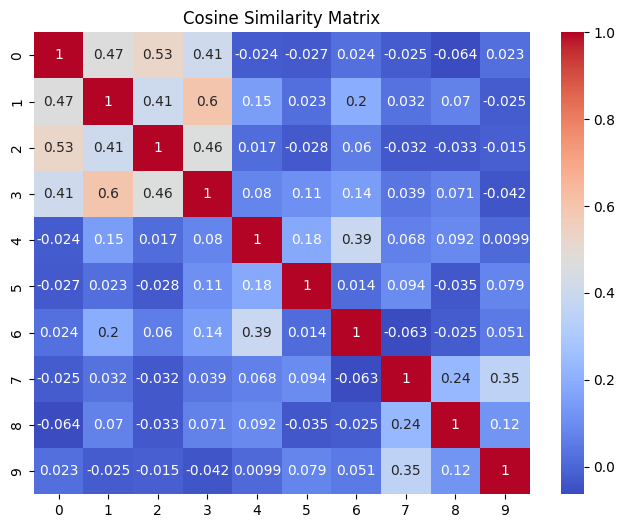

In [6]:
similarity_matrix = cosine_similarity(embeddings)

df = pd.DataFrame(similarity_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(df, annot=True, cmap="coolwarm")
plt.title("Cosine Similarity Matrix")
plt.show()


In [7]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

query_similarity = cosine_similarity(query_embedding, embeddings)[0]

top_indices = query_similarity.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 most similar sentences:\n")

for i in top_indices:
    print(sentences[i])
    print("Similarity Score:", query_similarity[i])
    print()

Query: The bowler took three wickets in one over

Top 2 most similar sentences:

The bowler delivered a fast yorker that hit the stumps.
Similarity Score: 0.6282083

The batsman scored a century in the final match.
Similarity Score: 0.567912

